# RUN ONCE

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")

print("Path to dataset files:", path)

100%|██████████| 86.8M/86.8M [00:10<00:00, 8.70MB/s]

Extracting files...


Path to dataset files: C:\Users\rohanb\.cache\kagglehub\datasets\sartajbhuvaji\brain-tumor-classification-mri\versions\3


# CODE STARTS HERE

In [1]:
import torch
print(torch.cuda.is_available())      # Should print: True
print(torch.cuda.get_device_name(0))  # Should print: NVIDIA GeForce RTX 5070 Laptop GPU

True
NVIDIA GeForce RTX 5070 Laptop GPU


## Imports

In [1]:
import os
import math
import random
from typing import Dict, Tuple

import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split

import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision import models

from sklearn.model_selection import KFold

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# Reproducibility settings
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Loading in Data from Workspace

In [2]:
DATA_DIR = "../Data"

TRAIN_DIR = os.path.join(DATA_DIR, "Training")
TEST_DIR   = os.path.join(DATA_DIR, "Testing")

assert os.path.isdir(TRAIN_DIR), f"Train directory not found: {TRAIN_DIR}"
assert os.path.isdir(TEST_DIR), f"Val directory not found: {TEST_DIR}"

print("Train dir:", TRAIN_DIR)
print("Test dir:", TEST_DIR)


Train dir: ../Data\Training
Test dir: ../Data\Testing


## Image Normalization and Transforms

In [3]:
IMG_SIZE = 224

# ImageNet normalization stats (used by pretrained models)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def to_3ch(x: torch.Tensor) -> torch.Tensor:
    # x is shape (1,H,W) after Grayscale+ToTensor.
    # Repeat to (3,H,W) for ImageNet-pretrained CNNs.
    return x.repeat(3, 1, 1)

train_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20), # Was 7 originally
    transforms.ToTensor(),
    transforms.Lambda(to_3ch),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(to_3ch),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


## Class Labeling

In [4]:
train_ds = ImageFolder(TRAIN_DIR, transform=train_tfms)
test_ds   = ImageFolder(TEST_DIR,   transform=test_tfms)

print("Class-to-index mapping:", train_ds.class_to_idx)
class_names = train_ds.classes

Class-to-index mapping: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


## Download ResNet18

In [5]:
def get_resnet18_pretrained(num_classes: int):
    try:
        # Newer torchvision
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
    except Exception:
        # Older torchvision
        model = models.resnet18(pretrained=True)

    # Replace final layer: `fc` is the classifier in ResNet
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

model = get_resnet18_pretrained(num_classes=len(class_names)).to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
# TODO try changing the number of layers to unfreeze

def set_trainable(module: nn.Module, trainable: bool):
    for p in module.parameters():
        p.requires_grad = trainable

# Freeze everything
set_trainable(model, False)

# Unfreeze only the head
set_trainable(model.fc, True)

# Sanity check: count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} / {all_params:,} ({100*trainable_params/all_params:.2f}%)")

Trainable params: 2,052 / 11,178,564 (0.02%)


## Training and Evaluating Functions

In [7]:
@torch.no_grad()
def evaluate(model, loader, criterion) -> Tuple[float, float, np.ndarray, np.ndarray]:
    # Returns: avg_loss, accuracy, y_true (N,), y_prob (N,2)
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    y_true_all = []
    y_prob_all = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total += x.size(0)

        probs = torch.softmax(logits, dim=1)  # (B,2)
        y_true_all.append(y.detach().cpu().numpy())
        y_prob_all.append(probs.detach().cpu().numpy())

    y_true_all = np.concatenate(y_true_all, axis=0)
    y_prob_all = np.concatenate(y_prob_all, axis=0)
    return total_loss / total, total_correct / total, y_true_all, y_prob_all

def train_model (model, train_loader, val_loader, epochs=10, lr=1e-3, weight_decay=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad],
                           lr=lr, weight_decay=weight_decay)    # Training loop
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):  # Run for 10 epochs
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            running_correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        
        train_loss = running_loss / total
        train_acc = running_correct / total
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}")
        
    return history

def plot_curves(history: Dict[str, list]):
    plt.figure(figsize=(7,4))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss curves")
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(history["train_acc"], label="train_acc")
    plt.plot(history["val_acc"], label="val_acc")
    plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.title("Accuracy curves")
    plt.show()

## Training Loop

In [24]:
BATCH_SIZE = 32  # ResNet is reasonably light; adjust batch size for your hardware

# Create folder to save models
MODELS_DIR = "../Models"
os.makedirs(MODELS_DIR, exist_ok=True)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

fold_history = {}
fold_models = {}

unfreeze_layers = [
    ["fc"],
    ["layer4", "fc"],
    ["layer3", "layer4", "fc"],
    ["layer2", "layer3", "layer4", "fc"],
    ["layer1", "layer2", "layer3", "layer4", "fc"],
]

for fold, (train_idx, val_idx) in enumerate(kf.split(train_ds)):
    print(f"Fold {fold+1}/5")
    # Create subset samplers for this fold
    train_subset = Subset(ImageFolder(TRAIN_DIR, transform=train_tfms), train_idx)
    val_subset = Subset(ImageFolder(TRAIN_DIR, transform=test_tfms), val_idx)

    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    model = get_resnet18_pretrained(num_classes=len(class_names)).to(device)
    set_trainable(model, False)
    
    for layer in unfreeze_layers[fold]:
        set_trainable(getattr(model, layer), True)

    history_head = train_model(model, train_loader, val_loader, epochs=10, lr=1e-4, weight_decay=1e-4)
    
    fold_history[fold] = history_head

    fold_models[fold] = model
    
    # Save the model
    model_path = os.path.join(MODELS_DIR, f"resnet18_fold_{fold}_model.pth")
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

Fold 1/5
Epoch 00/10 | train_loss=0.0435 train_acc=0.284 | val_loss=1.2989 val_acc=0.366
Epoch 01/10 | train_loss=0.0385 train_acc=0.437 | val_loss=1.1507 val_acc=0.535
Epoch 02/10 | train_loss=0.0347 train_acc=0.570 | val_loss=1.0554 val_acc=0.620
Epoch 03/10 | train_loss=0.0318 train_acc=0.633 | val_loss=0.9791 val_acc=0.674
Epoch 04/10 | train_loss=0.0293 train_acc=0.692 | val_loss=0.9181 val_acc=0.704
Epoch 05/10 | train_loss=0.0276 train_acc=0.711 | val_loss=0.8797 val_acc=0.709
Epoch 06/10 | train_loss=0.0262 train_acc=0.728 | val_loss=0.8290 val_acc=0.730
Epoch 07/10 | train_loss=0.0247 train_acc=0.755 | val_loss=0.8042 val_acc=0.711
Epoch 08/10 | train_loss=0.0242 train_acc=0.749 | val_loss=0.7756 val_acc=0.746
Epoch 09/10 | train_loss=0.0231 train_acc=0.762 | val_loss=0.7499 val_acc=0.775
Model saved to ../Models\resnet18_fold_0_model.pth
Fold 2/5
Epoch 00/10 | train_loss=0.0150 train_acc=0.824 | val_loss=0.3082 val_acc=0.885
Epoch 01/10 | train_loss=0.0073 train_acc=0.913 | v

## Plotting Loss and Training/Validation Accuracy Curves

In [20]:
model = get_resnet18_pretrained(num_classes=len(class_names)).to(device)
model_path = "../Models/2026-03-29_16-38-29_model.pth"
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

Fold 1 curves:


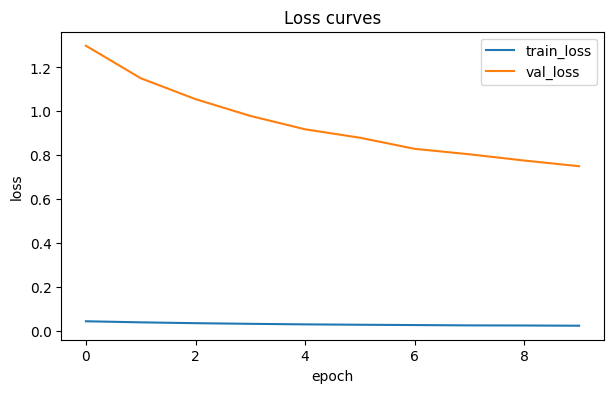

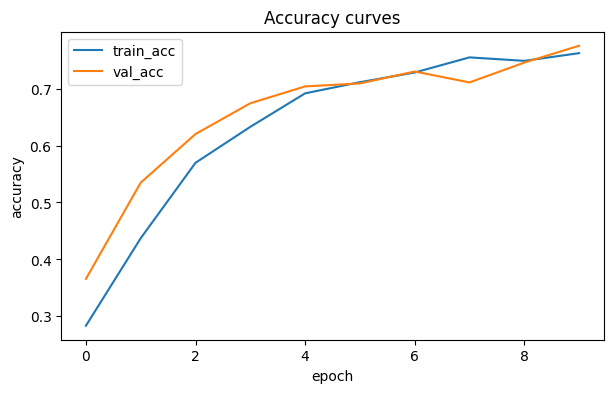

Fold 2 curves:


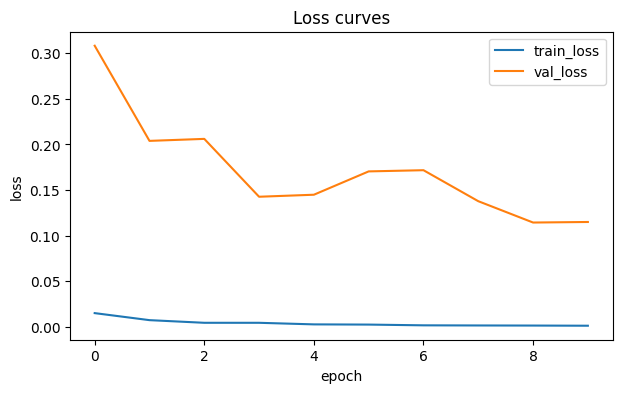

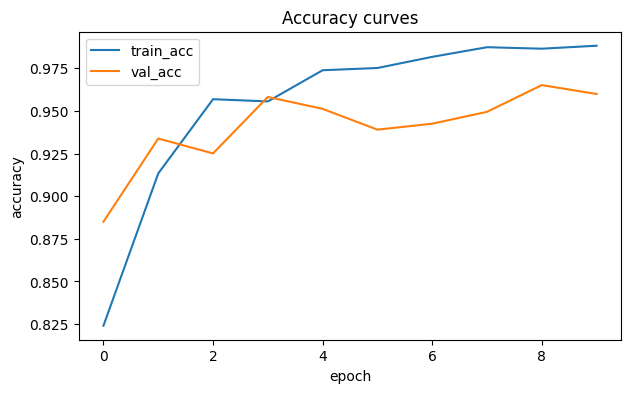

Fold 3 curves:


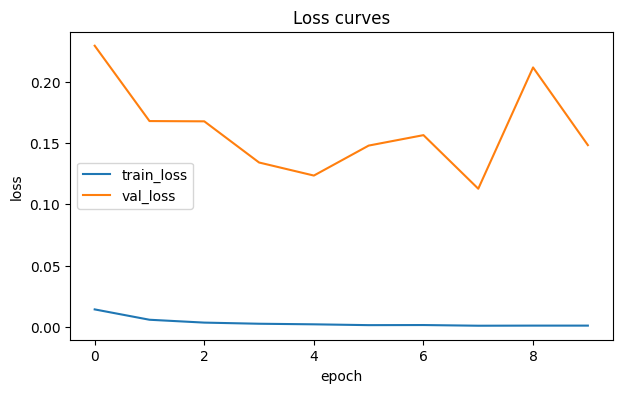

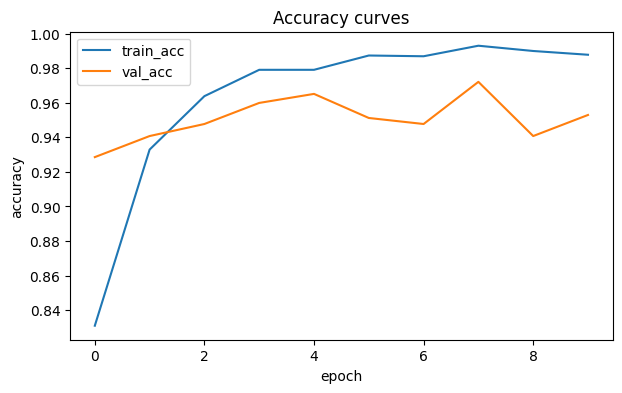

Fold 4 curves:


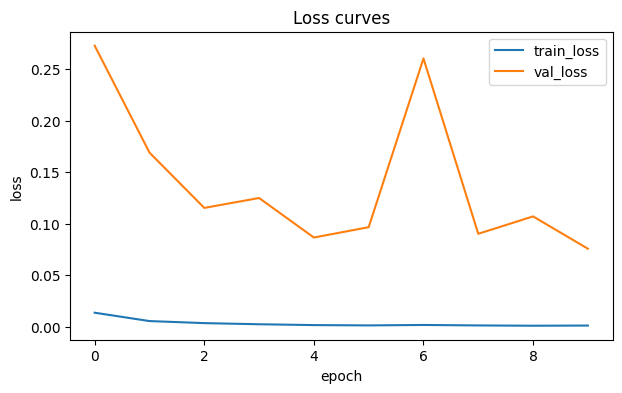

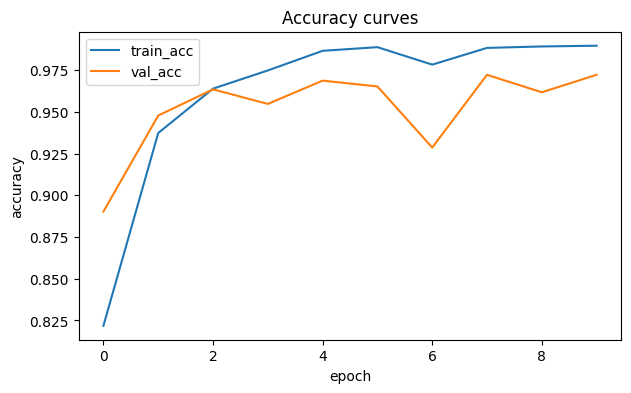

Fold 5 curves:


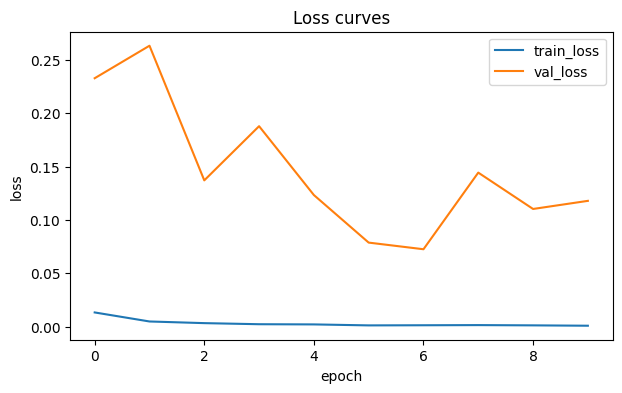

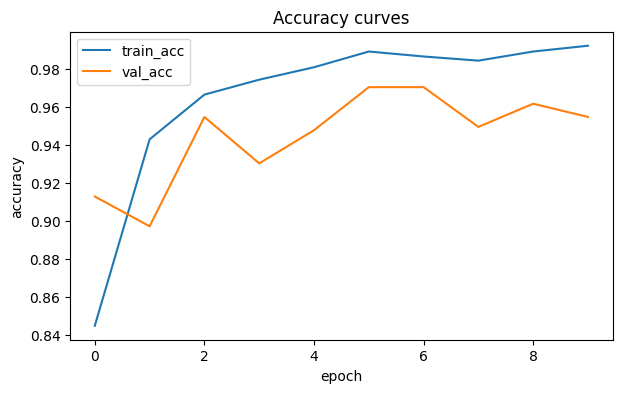

In [25]:
for fold, history in fold_history.items():
    print(f"Fold {fold+1} curves:")
    plot_curves(history)

## (Run this to load in already-trained model weights)

In [ ]:
# Load saved models from disk (instead of retraining on kernel restart)
MODELS_DIR = "../Models"

fold_models_loaded = {}

for fold in range(5):
    model_path = os.path.join(MODELS_DIR, f"fold_{fold}_model.pth")
    if os.path.exists(model_path):
        model = get_resnet18_pretrained(num_classes=len(class_names)).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        fold_models_loaded[fold] = model
        print(f"Loaded model from {model_path}")
    else:
        print(f"Model not found at {model_path}")

# Use loaded models for subsequent analysis
fold_models = fold_models_loaded
print(f"\nSuccessfully loaded {len(fold_models)} models from disk")

## Evaluation: Confusion Matrices


Fold 1 - Test Set Evaluation
Test Accuracy: 0.487


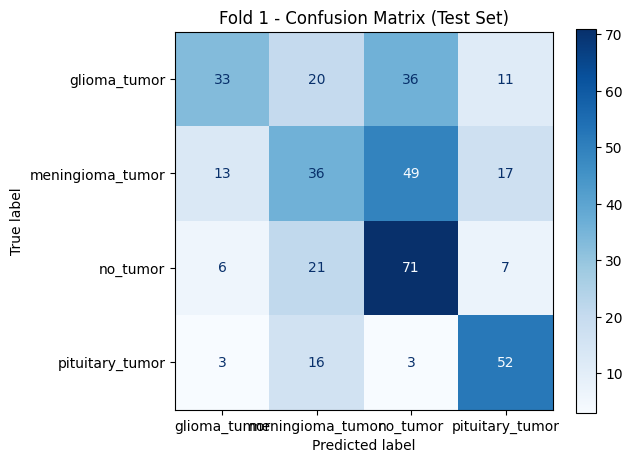


Fold 2 - Test Set Evaluation
Test Accuracy: 0.739


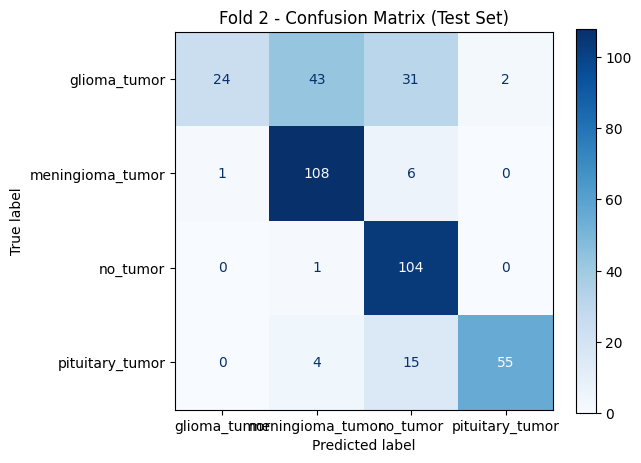


Fold 3 - Test Set Evaluation
Test Accuracy: 0.784


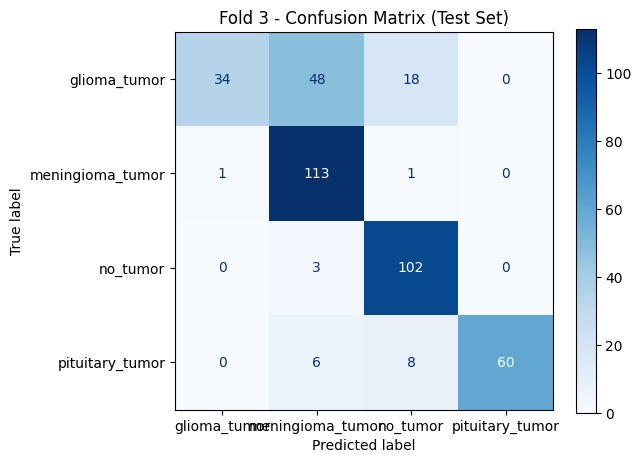


Fold 4 - Test Set Evaluation
Test Accuracy: 0.726


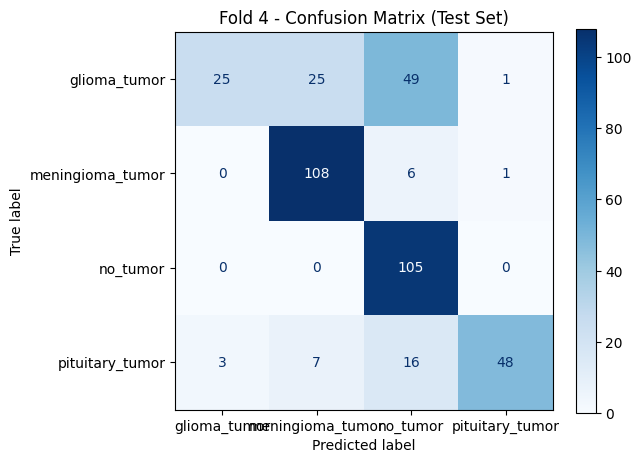


Fold 5 - Test Set Evaluation
Test Accuracy: 0.774


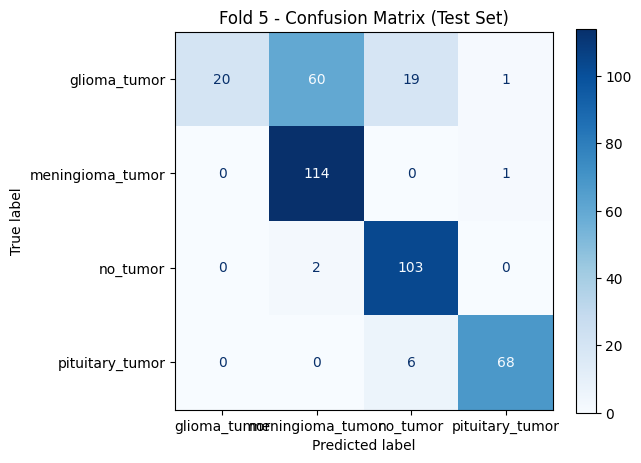

In [26]:
# Evaluate each fold on test set and display confusion matrices
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
criterion = nn.CrossEntropyLoss()

for fold, model in fold_models.items():
    print(f"\nFold {fold+1} - Test Set Evaluation")
    
    # Get predictions on test set using the trained model
    test_loss, test_acc, y_true, y_prob = evaluate(model, test_loader, criterion)
    y_pred = y_prob.argmax(axis=1)
    
    print(f"Test Accuracy: {test_acc:.3f}")
    
    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Fold {fold+1} - Confusion Matrix (Test Set)")
    plt.tight_layout()
    plt.show()

## FINAL MODEL

In [ ]:
import os
from datetime import datetime

BATCH_SIZE = 64  # ResNet is reasonably light; adjust batch size for your hardware, increaswed from 32 to 64

# Create folder to save models
MODELS_DIR = "../Models"
os.makedirs(MODELS_DIR, exist_ok=True)

val_dataset, test_dataset = random_split(test_ds, [len(test_ds)-100, 100], generator=torch.Generator().manual_seed(SEED))


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model = get_resnet18_pretrained(num_classes=len(class_names)).to(device)

set_trainable(model, False)
set_trainable(model.fc, True)

history_head = train_model(model, train_loader, val_loader, epochs=20, lr=1e-4, weight_decay=1e-4)

# Save the model
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
model_path = os.path.join(MODELS_DIR, f"resnet18_{timestamp}_model.pth")
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

## Evaluation: GradCAM

GradCAM Visualization on Test Samples:


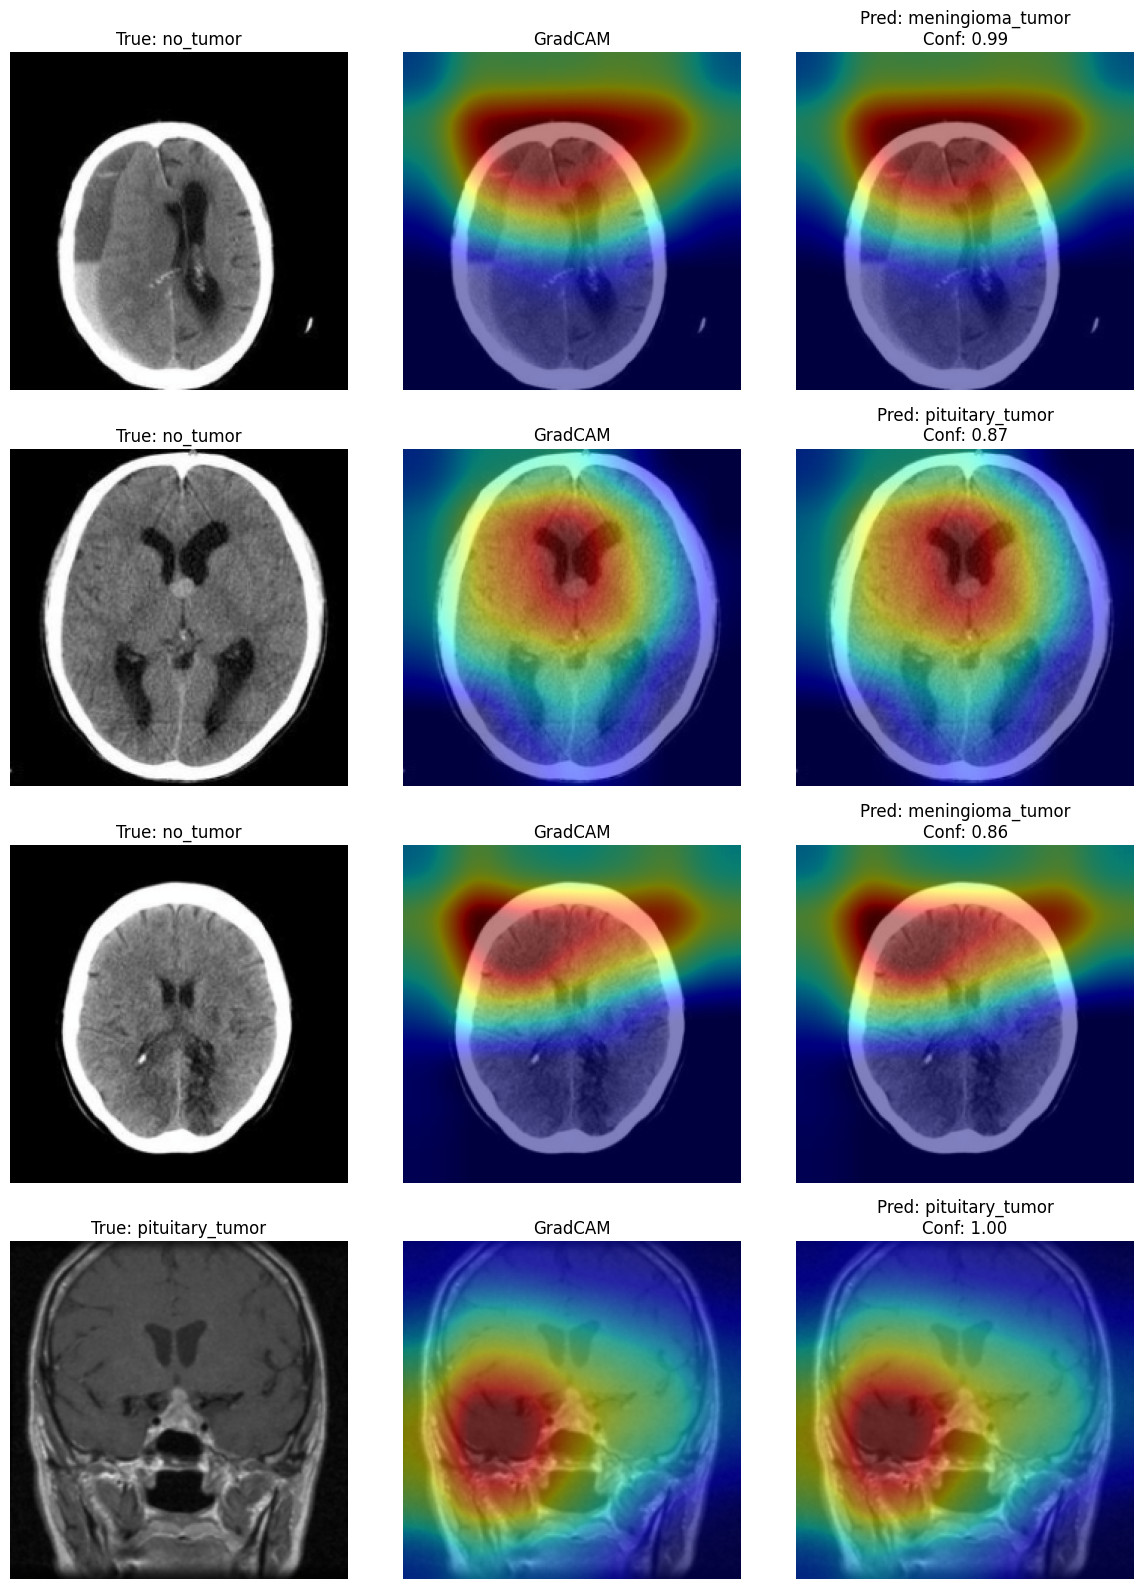

In [19]:
class GradCAM:
    """Compute and visualize Grad-CAM (Gradient-weighted Class Activation Mapping)"""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_gradients)
    
    def _save_activations(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def __call__(self, x, class_idx=None):
        """
        Args:
            x: input image tensor (B, C, H, W)
            class_idx: target class index (if None, uses predicted class)
        Returns:
            cam: class activation map (H, W)
        """
        self.model.eval()
        B, C, H, W = x.shape
        
        # Forward pass
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1)[0].item()
        
        # Backward pass
        self.model.zero_grad()
        logits[0, class_idx].backward()
        
        # Compute CAM
        gradients = self.gradients[0]  # (C_feat, H_feat, W_feat)
        activations = self.activations[0]  # (C_feat, H_feat, W_feat)
        
        weights = gradients.mean(dim=(1, 2))  # (C_feat,)
        cam = torch.sum(weights[:, None, None] * activations, dim=0)  # (H_feat, W_feat)
        cam = torch.relu(cam)
        
        # Normalize to [0, 1]
        if cam.max() > 0:
            cam = cam / cam.max()
        
        return cam.cpu().numpy()

def show_gradcam(model, images, labels, class_names, num_samples=4):
    """Visualize GradCAM for sample predictions"""
    model.eval()
    
    # Use layer4[-1] (last residual block) as target layer for ResNet
    gradcam = GradCAM(model, model.layer4[-1])
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(min(num_samples, len(images))):
        img = images[i:i+1].to(device)
        true_label = class_names[labels[i].item()]
        
        # Get prediction
        with torch.no_grad():
            logits = model(img)
            pred_idx = logits.argmax(dim=1)[0].item()
            pred_label = class_names[pred_idx]
            confidence = torch.softmax(logits, dim=1)[0, pred_idx].item()
        
        # Get GradCAM
        cam = gradcam(img, pred_idx)
        
        # Denormalize image for visualization
        img_np = img[0].permute(1, 2, 0).cpu().numpy()
        img_np = (img_np * np.array(IMAGENET_STD)) + np.array(IMAGENET_MEAN)
        img_np = np.clip(img_np, 0, 1)
        
        # Resize CAM to image size
        cam_resized = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE)))
        cam_resized = cam_resized / 255.0
        
        # Original image
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f"True: {true_label}")
        axes[i, 0].axis("off")
        
        # GradCAM heatmap
        axes[i, 1].imshow(img_np)
        axes[i, 1].imshow(cam_resized, cmap='jet', alpha=0.5)
        axes[i, 1].set_title(f"GradCAM")
        axes[i, 1].axis("off")
        
        # Overlay with text
        axes[i, 2].imshow(img_np)
        axes[i, 2].imshow(cam_resized, cmap='jet', alpha=0.5)
        axes[i, 2].set_title(f"Pred: {pred_label}\nConf: {confidence:.2f}")
        axes[i, 2].axis("off")
    
    plt.tight_layout()
    plt.show()

# Visualize GradCAM on test samples
from PIL import Image

# Use the last trained model
test_samples_loader = DataLoader(test_ds, batch_size=10, shuffle=True, num_workers=0)
test_images, test_labels = next(iter(test_samples_loader))

print("GradCAM Visualization on Test Samples:")
show_gradcam(model, test_images, test_labels, class_names, num_samples=4)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Evaluate all folds and compute class-wise metrics
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
criterion = nn.CrossEntropyLoss()

all_metrics = []

for fold, model in fold_models.items():
    print(f"\n{'='*60}")
    print(f"Fold {fold+1} - Detailed Metrics")
    print('='*60)
    
    # Get predictions on test set
    test_loss, test_acc, y_true, y_prob = evaluate(model, test_loader, criterion)
    y_pred = y_prob.argmax(axis=1)
    
    # Overall accuracy
    overall_accuracy = accuracy_score(y_true, y_pred)
    print(f"\nOverall Accuracy: {overall_accuracy:.4f}")
    
    # Class-wise metrics
    print(f"\n{'Class':<20} {'Sensitivity':<15} {'Specificity':<15} {'F1-Score':<15}")
    print("-" * 65)
    
    fold_metrics = {'Fold': fold + 1, 'Overall_Accuracy': overall_accuracy}
    
    for class_idx, class_name in enumerate(class_names):
        # Sensitivity (Recall/TPR): True Positive Rate for this class
        sensitivity = recall_score(y_true, y_pred, labels=[class_idx], average=None)[0]
        
        # Specificity: True Negative Rate for this class
        # TP / (TP + FN) for class, then (TN / (TN + FP)) for all other classes
        tn = np.sum((y_true != class_idx) & (y_pred != class_idx))
        fp = np.sum((y_true != class_idx) & (y_pred == class_idx))
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        # F1 Score
        f1 = f1_score(y_true, y_pred, labels=[class_idx], average=None)[0]
        
        print(f"{class_name:<20} {sensitivity:<15.4f} {specificity:<15.4f} {f1:<15.4f}")
        
        fold_metrics[f'{class_name}_Sensitivity'] = sensitivity
        fold_metrics[f'{class_name}_Specificity'] = specificity
        fold_metrics[f'{class_name}_F1'] = f1
    
    all_metrics.append(fold_metrics)

# Create summary dataframe across all folds
print(f"\n{'='*60}")
print("Summary: Average Metrics Across All Folds")
print('='*60)

metrics_df = pd.DataFrame(all_metrics)
print("\nDetailed Metrics Table:")
print(metrics_df.to_string(index=False))

# Compute mean and std across folds
print(f"\n{'='*60}")
print("Mean and Std Dev Across Folds")
print('='*60)

summary_stats = {}
for col in metrics_df.columns:
    if col != 'Fold':
        mean_val = metrics_df[col].mean()
        std_val = metrics_df[col].std()
        summary_stats[col] = f"{mean_val:.4f} ± {std_val:.4f}"

summary_df = pd.DataFrame(list(summary_stats.items()), columns=['Metric', 'Mean ± Std'])
print("\n" + summary_df.to_string(index=False))